# 结果分析


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import src.utils.logger as _L
from src.data.preprocess import to_panel
from src.evaluation.metrics import calc_ic_series, calc_icir, group_returns
from src.gp.evaluator import evaluate, to_wide
from src.utils.logger import load_stats

# ---- 0) 仓库根，所有路径基于它拼，与 notebook 的 cwd 无关 ----
REPO = Path(_L.__file__).parents[2]
LOG_ROOT = REPO / "results" / "logs"


In [2]:
# ---- 1) 自动找最新实验目录 ----
exp_dirs = sorted(LOG_ROOT.glob("exp_*"))
assert exp_dirs, f"{LOG_ROOT} 下没有 exp_*——确认在服务器上跑、且实验已产生目录"
log_dir = max(exp_dirs, key=lambda p: p.stat().st_mtime)
print("分析:", log_dir)


分析: /public/home/LEEyf/FactorMiner/results/logs/exp_20260601_174746


exp_20260601_174746: 已记录 50 代
目录内文件: ['run.log', 'stats.jsonl', 'top_factors.pkl']


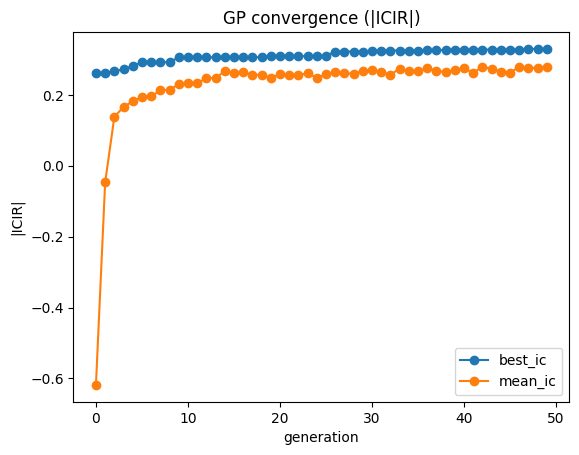

In [3]:
# ---- 2) 收敛曲线（best/mean 随代数，可边跑边看）----
records = load_stats(log_dir)
print(f"{log_dir.name}: 已记录 {len(records)} 代")
print("目录内文件:", [p.name for p in log_dir.iterdir()])

if not records:
    raise SystemExit(
        "stats.jsonl 为空。两种可能：\n"
        "  (a) 全量刚启动、gen 0 还没算完（500 个体约 1-2 分钟才写第一行）→ 稍等再跑；\n"
        "  (b) engine.run_gp 没调用 log_generation（见下方检查）。"
    )

stats = pd.DataFrame(records)
stats.plot(x="gen", y=["best_ic", "mean_ic"], marker="o", title="GP convergence (|ICIR|)")
plt.ylabel("|ICIR|")
plt.xlabel("generation")
plt.show()

In [4]:
# ---- 3) 取最佳因子（含 Node 对象；需等全量跑完、pkl 生成）----
with open(log_dir / "top_factors.pkl", "rb") as fh:
    results = pickle.load(fh)
best_tree, best_score = results[0]
print(f"最佳 |ICIR|={best_score:.4f}\n{best_tree}")

最佳 |ICIR|=0.3296
sub(neg(abs(delta(ts_std(volume)))), ts_std(sub(mul(add(div(amount, high), high), low), add(ts_mean(ts_mean(amount)), log(delta(close))))))


In [5]:
# ---- 4) 加载数据，重算该因子 ----
prices = pd.read_parquet(REPO / "data" / "cache" / "prices_clean.parquet")
wide = to_wide(prices.drop(columns=["fwd_ret"]))
fwd = to_panel(prices, "fwd_ret")
factor = evaluate(best_tree, wide)

mean IC=0.0434 | ICIR=0.3296 | IC>0 占比=61.8%


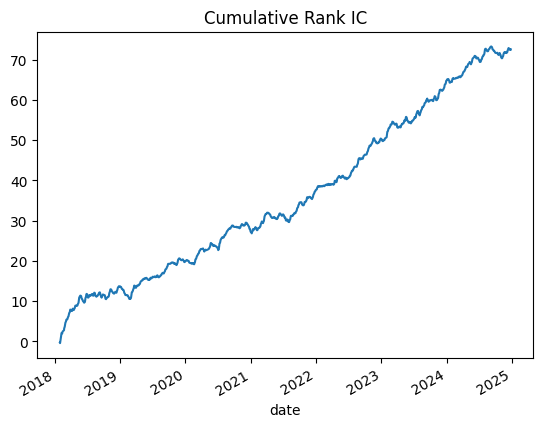

In [6]:
# ---- 5) IC 序列 + 累计 IC（看稳定性）----
ic = calc_ic_series(factor, fwd).dropna()
print(f"mean IC={ic.mean():.4f} | ICIR={calc_icir(ic):.4f} | IC>0 占比={(ic > 0).mean():.1%}")
ic.cumsum().plot(title="Cumulative Rank IC")
plt.show()

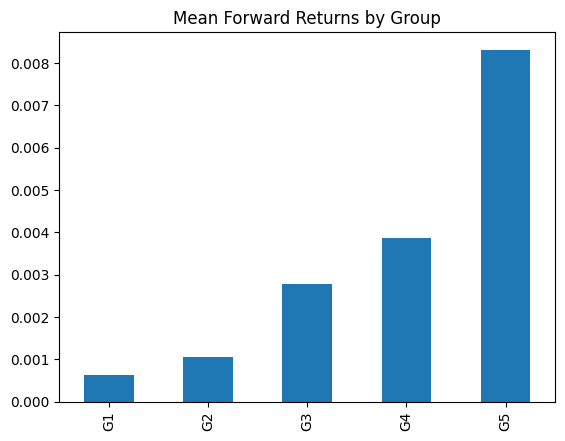

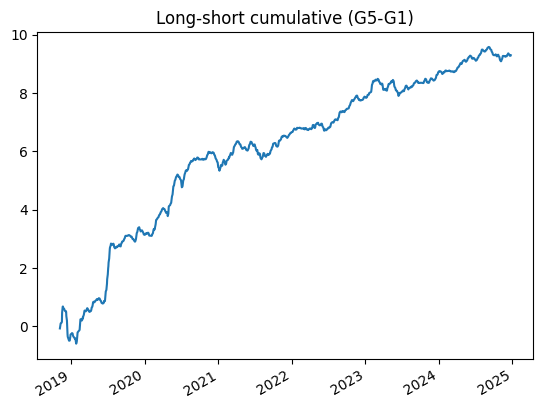

In [7]:
# ---- 6) 分组回测：5 组平均未来收益（好因子应大致单调）----
grp = group_returns(factor, fwd, n_groups=5)
grp.mean().plot(kind="bar", title="Mean Forward Returns by Group")
plt.show()
(grp["G5"] - grp["G1"]).cumsum().plot(title="Long-short cumulative (G5-G1)")
plt.show()
